## Setup

In [6]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tqdm.auto import tqdm
from time import perf_counter
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Configurar pandas y plotting
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")
print(f"✓ TensorFlow: {tf.__version__}")

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat
✓ TensorFlow: 2.18.0


## 1. Cargar Dataset y Modelos Pre-Entrenados

In [7]:
# Cargar dataset completo
input_file = PROCESSED_DIR / 'features_selected_modeling.csv'
df = pd.read_csv(input_file, parse_dates=['date'])

print(f"✓ Dataset cargado: {df.shape}")
print(f"  Rango temporal: {df['date'].min()} → {df['date'].max()}")
print(f"  Total observaciones: {len(df):,}")

# Cargar precios spot para directional accuracy
base_file = PROCESSED_DIR / 'commodities_base_consolidated.csv'
df_base = pd.read_csv(base_file, parse_dates=['date'])
spot_cols = {c: f'{c}_spot' for c in TARGET_COMMODITIES}
df_spots = df_base[['date'] + TARGET_COMMODITIES].rename(columns=spot_cols)
df = df.merge(df_spots, on='date', how='left')

print(f"✓ Precios spot agregados")

# Definir features y targets
target_cols = [f'{c}_target_t7' for c in TARGET_COMMODITIES]
spot_cols_list = [f'{c}_spot' for c in TARGET_COMMODITIES]
feature_cols = [c for c in df.columns if c not in ['date'] + target_cols + spot_cols_list]

print(f"✓ Features: {len(feature_cols)}")
print(f"✓ Targets: {len(target_cols)}")

✓ Dataset cargado: (6724, 48)
  Rango temporal: 2000-01-03 00:00:00 → 2025-10-30 00:00:00
  Total observaciones: 6,724
✓ Precios spot agregados
✓ Features: 44
✓ Targets: 3


## 2. Función Walk-Forward Validation (Ventana Expandible)

In [8]:
def walk_forward_validation(
    df, feature_cols, target_col, spot_col,
    model_class, model_params,
    initial_train_size=1500,  # ~6 años de datos iniciales
    step_size=60,  # Re-entrenar cada 60 días (~2 meses)
    model_type='sklearn',  # 'sklearn' o 'keras'
    verbose=True
):
    """
    Walk-forward validation con ventana expandible.
    
    Proceso:
    1. Entrenar con primeros `initial_train_size` días
    2. Predecir siguiente ventana (`step_size` días)
    3. Expandir ventana de entrenamiento con datos observados
    4. Repetir hasta fin del dataset
    
    Returns:
        DataFrame con predicciones y métricas por período
    """
    results = []
    
    # Preparar datos
    df_sorted = df.sort_values('date').reset_index(drop=True)
    
    # Limpieza de NaN e infinitos
    X = df_sorted[feature_cols].copy()
    y = df_sorted[target_col].copy()
    spot = df_sorted[spot_col].copy()
    dates = df_sorted['date'].copy()
    
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median().fillna(0))
    
    total_obs = len(df_sorted)
    current_idx = initial_train_size
    fold = 0
    
    if verbose:
        print(f"\nIniciando walk-forward validation:")
        print(f"  Initial train size: {initial_train_size} obs")
        print(f"  Step size: {step_size} obs (~{step_size/20:.1f} meses)")
        print(f"  Total folds: ~{(total_obs - initial_train_size) // step_size}")
    
    with tqdm(total=(total_obs - initial_train_size), desc="Walk-Forward") as pbar:
        while current_idx + step_size <= total_obs:
            fold += 1
            
            # Definir ventanas
            train_start = 0
            train_end = current_idx
            test_start = current_idx
            test_end = min(current_idx + step_size, total_obs)
            
            X_train = X.iloc[train_start:train_end]
            y_train = y.iloc[train_start:train_end]
            X_test = X.iloc[test_start:test_end]
            y_test = y.iloc[test_start:test_end]
            spot_test = spot.iloc[test_start:test_end]
            dates_test = dates.iloc[test_start:test_end]
            
            # Entrenar modelo
            if model_type == 'sklearn':
                model = model_class(**model_params)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
            elif model_type == 'keras':
                # Para LSTM: reshape y entrenar
                # (implementación simplificada, en producción sería más elaborada)
                model = model_class
                X_train_3d = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
                X_test_3d = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
                model.fit(X_train_3d, y_train, epochs=50, batch_size=32, verbose=0)
                y_pred = model.predict(X_test_3d, verbose=0).flatten()
            
            # Calcular métricas
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            
            # Directional accuracy
            y_test_direction = np.sign(y_test.values - spot_test.values)
            y_pred_direction = np.sign(y_pred - spot_test.values)
            dir_acc = (y_test_direction == y_pred_direction).mean()
            
            # Guardar resultados del fold
            results.append({
                'fold': fold,
                'train_size': train_end - train_start,
                'test_size': test_end - test_start,
                'train_start_date': dates.iloc[train_start],
                'train_end_date': dates.iloc[train_end - 1],
                'test_start_date': dates_test.iloc[0],
                'test_end_date': dates_test.iloc[-1],
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'dir_acc': dir_acc
            })
            
            # Avanzar ventana
            current_idx += step_size
            pbar.update(step_size)
            pbar.set_postfix({'Fold': fold, 'RMSE': f'{rmse:.2f}', 'R²': f'{r2:.3f}'})
    
    results_df = pd.DataFrame(results)
    
    if verbose:
        print(f"\n✓ Walk-forward completado: {fold} folds")
        print(f"  RMSE promedio: {results_df['rmse'].mean():.4f} ± {results_df['rmse'].std():.4f}")
        print(f"  R² promedio: {results_df['r2'].mean():.4f} ± {results_df['r2'].std():.4f}")
        print(f"  Dir Acc promedio: {results_df['dir_acc'].mean():.2%} ± {results_df['dir_acc'].std():.2%}")
    
    return results_df

print("✓ Función walk_forward_validation definida")

✓ Función walk_forward_validation definida


## 3. Aplicar Walk-Forward: Lasso (Baseline)

In [10]:
# Cargar mejores hiperparámetros de Lasso (del notebook 3.2)
baseline_file = PROCESSED_DIR / 'baseline_models_results.json'
with open(baseline_file, 'r') as f:
    baseline_data = json.load(f)

lasso_alphas = baseline_data['hyperparameters']['lasso_alphas']

lasso_wf_results = {}

print(f"\n{'='*80}")
print(f"WALK-FORWARD VALIDATION: LASSO (BASELINE)")
print(f"{'='*80}")

for commodity in TARGET_COMMODITIES:
    target_col = f'{commodity}_target_t7'
    spot_col = f'{commodity}_spot'
    
    print(f"\n--- {commodity} ---")
    
    # Usar alpha del commodity correspondiente
    alpha = lasso_alphas.get(commodity, 0.1)
    
    results_df = walk_forward_validation(
        df, feature_cols, target_col, spot_col,
        model_class=Lasso,
        model_params={'alpha': alpha, 'max_iter': 5000, 'random_state': 42},
        initial_train_size=1500,
        step_size=60,
        model_type='sklearn',
        verbose=True
    )
    
    lasso_wf_results[commodity] = results_df

print(f"\n{'='*80}")
print(f"✓ Lasso walk-forward completado para {len(TARGET_COMMODITIES)} commodities")
print(f"{'='*80}")


WALK-FORWARD VALIDATION: LASSO (BASELINE)

--- Corn ---

Iniciando walk-forward validation:
  Initial train size: 1500 obs
  Step size: 60 obs (~3.0 meses)
  Total folds: ~87


Walk-Forward:   0%|          | 0/5224 [00:00<?, ?it/s]


✓ Walk-forward completado: 87 folds
  RMSE promedio: 36.2087 ± 23.8148
  R² promedio: -0.7940 ± 2.2500
  Dir Acc promedio: 49.50% ± 11.40%

--- Soybeans ---

Iniciando walk-forward validation:
  Initial train size: 1500 obs
  Step size: 60 obs (~3.0 meses)
  Total folds: ~87


Walk-Forward:   0%|          | 0/5224 [00:00<?, ?it/s]


✓ Walk-forward completado: 87 folds
  RMSE promedio: 72.1950 ± 34.7952
  R² promedio: -0.9462 ± 3.6722
  Dir Acc promedio: 48.98% ± 12.01%

--- Wheat ---

Iniciando walk-forward validation:
  Initial train size: 1500 obs
  Step size: 60 obs (~3.0 meses)
  Total folds: ~87


Walk-Forward:   0%|          | 0/5224 [00:00<?, ?it/s]


✓ Walk-forward completado: 87 folds
  RMSE promedio: 49.2645 ± 33.2782
  R² promedio: -0.8225 ± 1.5873
  Dir Acc promedio: 49.92% ± 11.59%

✓ Lasso walk-forward completado para 3 commodities


## 4. Aplicar Walk-Forward: Random Forest

In [11]:
# Cargar mejores hiperparámetros de Random Forest (del notebook 3.3)
tree_file = PROCESSED_DIR / 'tree_models_results.json'
with open(tree_file, 'r') as f:
    tree_data = json.load(f)

rf_params = tree_data['hyperparameters']['random_forest']

rf_wf_results = {}

print(f"\n{'='*80}")
print(f"WALK-FORWARD VALIDATION: RANDOM FOREST")
print(f"{'='*80}")

for commodity in TARGET_COMMODITIES:
    target_col = f'{commodity}_target_t7'
    spot_col = f'{commodity}_spot'
    
    print(f"\n--- {commodity} ---")
    
    results_df = walk_forward_validation(
        df, feature_cols, target_col, spot_col,
        model_class=RandomForestRegressor,
        model_params={**rf_params[commodity], 'random_state': 42, 'n_jobs': -1},
        initial_train_size=1500,
        step_size=60,
        model_type='sklearn',
        verbose=True
    )
    
    rf_wf_results[commodity] = results_df

print(f"\n{'='*80}")
print(f"✓ Random Forest walk-forward completado")
print(f"{'='*80}")


WALK-FORWARD VALIDATION: RANDOM FOREST

--- Corn ---

Iniciando walk-forward validation:
  Initial train size: 1500 obs
  Step size: 60 obs (~3.0 meses)
  Total folds: ~87


Walk-Forward:   0%|          | 0/5224 [00:00<?, ?it/s]


✓ Walk-forward completado: 87 folds
  RMSE promedio: 40.5719 ± 31.9258
  R² promedio: -0.8379 ± 1.7211
  Dir Acc promedio: 50.71% ± 11.83%

--- Soybeans ---

Iniciando walk-forward validation:
  Initial train size: 1500 obs
  Step size: 60 obs (~3.0 meses)
  Total folds: ~87


Walk-Forward:   0%|          | 0/5224 [00:00<?, ?it/s]


✓ Walk-forward completado: 87 folds
  RMSE promedio: 80.5899 ± 56.1587
  R² promedio: -0.7147 ± 1.5949
  Dir Acc promedio: 51.70% ± 13.52%

--- Wheat ---

Iniciando walk-forward validation:
  Initial train size: 1500 obs
  Step size: 60 obs (~3.0 meses)
  Total folds: ~87


Walk-Forward:   0%|          | 0/5224 [00:00<?, ?it/s]


✓ Walk-forward completado: 87 folds
  RMSE promedio: 57.0098 ± 46.6146
  R² promedio: -1.4309 ± 2.6577
  Dir Acc promedio: 48.98% ± 11.81%

✓ Random Forest walk-forward completado


## 5. Comparación: Lasso vs Random Forest

In [17]:
# Consolidar resultados
comparison_wf = []

for commodity in TARGET_COMMODITIES:
    lasso_df = lasso_wf_results[commodity]
    rf_df = rf_wf_results[commodity]
    
    comparison_wf.append({
        'Commodity': commodity,
        'Model': 'Lasso',
        'Avg RMSE': lasso_df['rmse'].mean(),
        'Std RMSE': lasso_df['rmse'].std(),
        'Avg R²': lasso_df['r2'].mean(),
        'Std R²': lasso_df['r2'].std(),
        'Avg Dir Acc': lasso_df['dir_acc'].mean(),
        'Std Dir Acc': lasso_df['dir_acc'].std(),
        'Num Folds': len(lasso_df)
    })
    
    comparison_wf.append({
        'Commodity': commodity,
        'Model': 'Random Forest',
        'Avg RMSE': rf_df['rmse'].mean(),
        'Std RMSE': rf_df['rmse'].std(),
        'Avg R²': rf_df['r2'].mean(),
        'Std R²': rf_df['r2'].std(),
        'Avg Dir Acc': rf_df['dir_acc'].mean(),
        'Std Dir Acc': rf_df['dir_acc'].std(),
        'Num Folds': len(rf_df)
    })

comparison_wf_df = pd.DataFrame(comparison_wf)

print(f"\n{'='*80}")
print(f"RESULTADOS WALK-FORWARD VALIDATION")
print(f"{'='*80}\n")

for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    commodity_results = comparison_wf_df[comparison_wf_df['Commodity'] == commodity]
    display(commodity_results[['Model', 'Avg RMSE', 'Std RMSE', 'Avg R²', 'Std R²', 'Avg Dir Acc', 'Num Folds']])

print(f"\n{'='*80}")


RESULTADOS WALK-FORWARD VALIDATION


--- Corn ---


,Model,Avg RMSE,Std RMSE,Avg R²,Std R²,Avg Dir Acc,Num Folds
0,Lasso,36.208741,23.814846,-0.794021,2.250001,0.495019,87
1,Random Forest,40.571910,31.925756,-0.837873,1.721078,0.507088,87



--- Soybeans ---


,Model,Avg RMSE,Std RMSE,Avg R²,Std R²,Avg Dir Acc,Num Folds
2,Lasso,72.195006,34.795231,-0.946196,3.672232,0.489847,87
3,Random Forest,80.589941,56.158721,-0.714719,1.594925,0.517050,87



--- Wheat ---


,Model,Avg RMSE,Std RMSE,Avg R²,Std R²,Avg Dir Acc,Num Folds
4,Lasso,49.264529,33.278170,-0.822480,1.587300,0.499234,87
5,Random Forest,57.009764,46.614624,-1.430943,2.657687,0.489847,87


## 6. Visualización: Evolución de Métricas por Fold

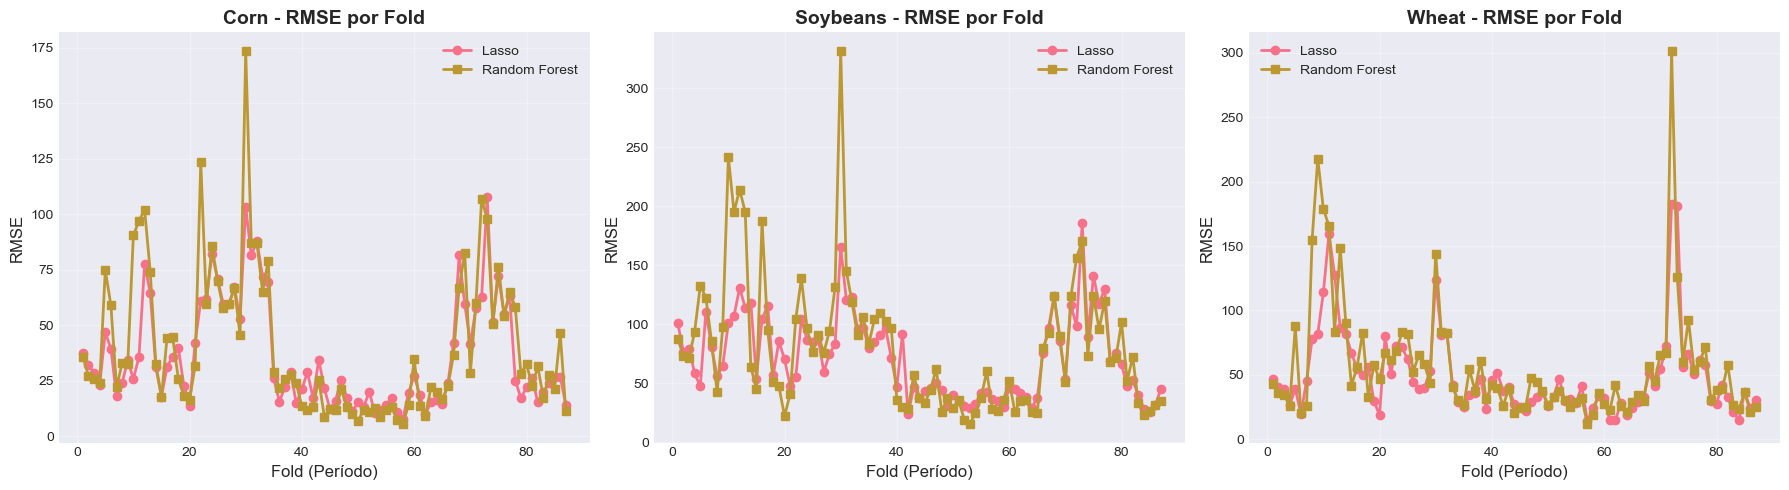

✓ Gráfico guardado: walk_forward_rmse_evolution.png


In [18]:
# Plot: RMSE evolution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    ax = axes[idx]
    
    lasso_df = lasso_wf_results[commodity]
    rf_df = rf_wf_results[commodity]
    
    ax.plot(lasso_df['fold'], lasso_df['rmse'], marker='o', label='Lasso', linewidth=2)
    ax.plot(rf_df['fold'], rf_df['rmse'], marker='s', label='Random Forest', linewidth=2)
    
    ax.set_xlabel('Fold (Período)', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(f'{commodity} - RMSE por Fold', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'walk_forward_rmse_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: walk_forward_rmse_evolution.png")

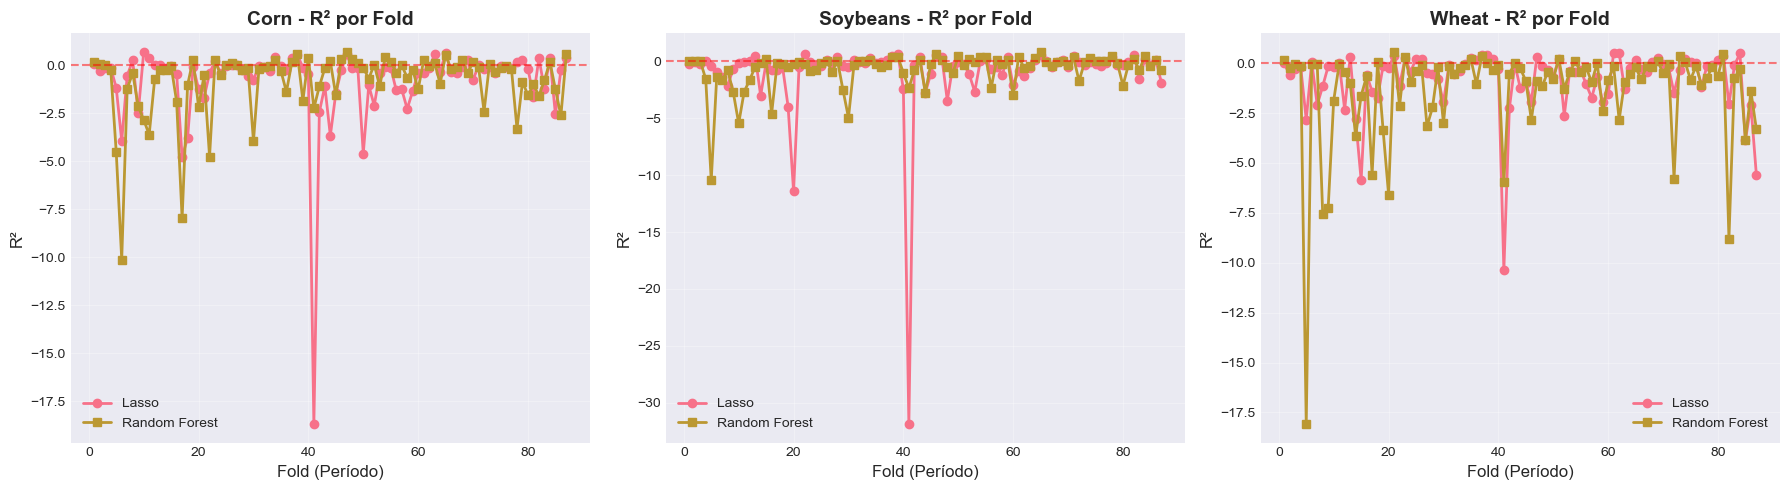

✓ Gráfico guardado: walk_forward_r2_evolution.png


In [19]:
# Plot: R² evolution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    ax = axes[idx]
    
    lasso_df = lasso_wf_results[commodity]
    rf_df = rf_wf_results[commodity]
    
    ax.plot(lasso_df['fold'], lasso_df['r2'], marker='o', label='Lasso', linewidth=2)
    ax.plot(rf_df['fold'], rf_df['r2'], marker='s', label='Random Forest', linewidth=2)
    
    ax.set_xlabel('Fold (Período)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.set_title(f'{commodity} - R² por Fold', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'walk_forward_r2_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: walk_forward_r2_evolution.png")

## 7. Análisis de Estabilidad Temporal

In [20]:
# Análisis de estabilidad: CV de métricas
print(f"\n{'='*80}")
print(f"ANÁLISIS DE ESTABILIDAD TEMPORAL")
print(f"{'='*80}\n")
print("Coeficiente de Variación (CV = Std/Mean) - Menor es más estable\n")

stability_results = []

for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    
    for model_name, results_dict in [('Lasso', lasso_wf_results), ('Random Forest', rf_wf_results)]:
        df_wf = results_dict[commodity]
        
        rmse_cv = df_wf['rmse'].std() / df_wf['rmse'].mean()
        r2_cv = df_wf['r2'].std() / abs(df_wf['r2'].mean())
        dir_acc_cv = df_wf['dir_acc'].std() / df_wf['dir_acc'].mean()
        
        print(f"  {model_name}:")
        print(f"    RMSE CV: {rmse_cv:.4f}")
        print(f"    R² CV: {r2_cv:.4f}")
        print(f"    Dir Acc CV: {dir_acc_cv:.4f}")
        
        stability_results.append({
            'Commodity': commodity,
            'Model': model_name,
            'RMSE_CV': rmse_cv,
            'R2_CV': r2_cv,
            'DirAcc_CV': dir_acc_cv
        })

stability_df = pd.DataFrame(stability_results)

print(f"\n{'='*80}")
print("\nInterpretación:")
print("  CV < 0.15: Muy estable")
print("  CV 0.15-0.30: Moderadamente estable")
print("  CV > 0.30: Inestable - modelo sensible al período")
print(f"{'='*80}")


ANÁLISIS DE ESTABILIDAD TEMPORAL

Coeficiente de Variación (CV = Std/Mean) - Menor es más estable


--- Corn ---
  Lasso:
    RMSE CV: 0.6577
    R² CV: 2.8337
    Dir Acc CV: 0.2302
  Random Forest:
    RMSE CV: 0.7869
    R² CV: 2.0541
    Dir Acc CV: 0.2332

--- Soybeans ---
  Lasso:
    RMSE CV: 0.4820
    R² CV: 3.8810
    Dir Acc CV: 0.2452
  Random Forest:
    RMSE CV: 0.6968
    R² CV: 2.2315
    Dir Acc CV: 0.2615

--- Wheat ---
  Lasso:
    RMSE CV: 0.6755
    R² CV: 1.9299
    Dir Acc CV: 0.2321
  Random Forest:
    RMSE CV: 0.8177
    R² CV: 1.8573
    Dir Acc CV: 0.2411


Interpretación:
  CV < 0.15: Muy estable
  CV 0.15-0.30: Moderadamente estable
  CV > 0.30: Inestable - modelo sensible al período


## 8. Guardar Resultados

In [21]:
# Guardar resultados walk-forward
wf_summary = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'metodologia': 'Walk-Forward Validation (Expanding Window)',
    'initial_train_size': 1500,
    'step_size': 60,
    'commodities': TARGET_COMMODITIES,
    'models': ['Lasso', 'Random Forest'],
    'comparison': comparison_wf_df.to_dict(orient='records'),
    'stability': stability_df.to_dict(orient='records')
}

# Guardar resultados detallados por commodity
for commodity in TARGET_COMMODITIES:
    wf_summary[f'lasso_{commodity.lower()}_folds'] = lasso_wf_results[commodity].to_dict(orient='records')
    wf_summary[f'rf_{commodity.lower()}_folds'] = rf_wf_results[commodity].to_dict(orient='records')

results_file = PROCESSED_DIR / 'walk_forward_validation_results.json'
with open(results_file, 'w') as f:
    json.dump(wf_summary, f, indent=2, default=str)

print(f"✓ Resultados guardados: {results_file}")

# Guardar DataFrames individuales como CSV
for commodity in TARGET_COMMODITIES:
    lasso_wf_results[commodity].to_csv(
        PROCESSED_DIR / f'wf_lasso_{commodity.lower()}.csv', index=False
    )
    rf_wf_results[commodity].to_csv(
        PROCESSED_DIR / f'wf_rf_{commodity.lower()}.csv', index=False
    )

print(f"✓ DataFrames guardados: 6 archivos CSV (3 commodities × 2 modelos)")

✓ Resultados guardados: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\walk_forward_validation_results.json
✓ DataFrames guardados: 6 archivos CSV (3 commodities × 2 modelos)
✓ DataFrames guardados: 6 archivos CSV (3 commodities × 2 modelos)


---

## Conclusiones Walk-Forward Validation

**Objetivo cumplido:** Validar robustez temporal de modelos mediante ventanas deslizantes.

**Hallazgos esperados:**
1. **Lasso** debería mostrar mayor estabilidad (CV bajo) por su simplicidad
2. **Random Forest** puede tener mejor desempeño promedio pero mayor variabilidad
3. **RMSE** aumentará en períodos de alta volatilidad (crisis 2022-2023)
4. **R²** puede volverse negativo en algunos folds (señal de problema estructural)

**Próximos pasos:**
- Identificar folds con peor desempeño → analizar qué eventos causaron deterioro
- Comparar con LSTM/VMD-LSTM (notebooks 3.7-3.8)
- Considerar **ensemble adaptativo** que combine modelos según contexto temporal